In [153]:
using Pkg
Pkg.add("GLM")

Pkg.add("ROCAnalysis")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("MLBase")

using DataFrames
using CSV
using GLM

using MLBase
using ROCAnalysis

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
              ✗ GR → GRIJuliaExt
              ✗ Plots → IJuliaExt
  0 dependencies successfully precompiled in 47 seconds. 335 already precompiled.
  2 dependencies errored.
  For a report of the errors see `julia> err`. To retry use `pkg> precompile`
   Resolving package versions...
   Installed ROCAnalysis ─ v0.3.6
    Updating `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
  [f535d66d] + ROCAnalysis v0.3.6
    Updating `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`
 [f535d66d] + ROCAnalysis v0.3.6
Precompiling packages...
   3128.2 ms  ✓ ROCAnalysis
              ✗ GR → GRIJuliaExt
              ✗ Plots → IJuliaExt
  1 dependency successfully precompiled in 13 seconds. 335 already precompiled.
  2

In [154]:
df = CSV.read("C:\\Users\\tunak\\OneDrive\\Masaüstü\\Sleep_health_and_lifestyle_dataset.csv",DataFrame)
first(df,5)

Row,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
,Int64,String7,Int64,String31,Float64,Int64,Int64,Int64,String15,String7,Int64,Int64,String15
1,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [156]:
Pkg.add("MLUtils")
using MLUtils

train, test = splitobs(df; at = 0.70, shuffle = true)

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
              ✗ GR → GRIJuliaExt
              ✗ Plots → IJuliaExt
  0 dependencies successfully precompiled in 12 seconds. 336 already precompiled.
  2 dependencies errored.
  For a report of the errors see `julia> err`. To retry use `pkg> precompile`


(ObsView(::DataFrame, ::Vector{Int64})
 262 observations, ObsView(::DataFrame, ::Vector{Int64})
 112 observations)

In [157]:
train_idx = train.indices
test_idx  = test.indices

train = df[train_idx, :]
test  = df[test_idx, :]

Row,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
,Int64,String7,Int64,String31,Float64,Int64,Int64,Int64,String15,String7,Int64,Int64,String15
1,332,Female,53,Engineer,8.4,9,30,3,Normal,125/80,65,5000,None
2,108,Male,37,Engineer,7.8,8,70,4,Normal Weight,120/80,68,7000,None
3,351,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
4,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
5,247,Male,44,Salesperson,6.3,6,45,7,Overweight,130/85,72,6000,Insomnia
6,88,Male,35,Engineer,7.2,8,60,4,Normal,125/80,65,5000,None
7,67,Male,32,Accountant,7.2,8,50,6,Normal Weight,118/76,68,7000,None
8,15,Male,29,Doctor,6.0,6,30,8,Normal,120/80,70,8000,None
9,242,Male,44,Salesperson,6.3,6,45,7,Overweight,130/85,72,6000,Insomnia


In [163]:
train_kopya = copy(train)
train_kopya[!, "Sleep Disorder"] = strip.(string.(train_kopya[!, "Sleep Disorder"]))
train_kopya[!, "Sleep Disorder"] = replace(train_kopya[!, "Sleep Disorder"], 
    "None" => "0.0", 
    "Insomnia" => "1.0", 
    "Sleep Apnea" => "1.0", )

train_kopya[!, "Sleep Disorder"] = parse.(Float64, train_kopya[!, "Sleep Disorder"])

test_kopya = copy(test)
test_kopya[!, "Sleep Disorder"] = strip.(string.(test_kopya[!, "Sleep Disorder"]))
test_kopya[!, "Sleep Disorder"] = replace(test_kopya[!, "Sleep Disorder"], 
    "None" => "0.0", 
    "Insomnia" => "1.0", 
    "Sleep Apnea" => "1.0", )

test_kopya[!, "Sleep Disorder"] = parse.(Float64, test_kopya[!, "Sleep Disorder"])




using DataFrames


function split_bp(bp_string)
    parts = split(bp_string, "/")
    return parse(Int, parts[1]), parse(Int, parts[2])
end


transform!(test_kopya, "Blood Pressure" => ByRow(x -> split_bp(x)[1]) => :BP_Systolic)
transform!(test_kopya, "Blood Pressure" => ByRow(x -> split_bp(x)[2]) => :BP_Diastolic)


select!(test_kopya, Not("Blood Pressure"))

using DataFrames


function split_bp(bp_string)
    parts = split(bp_string, "/")
    return parse(Int, parts[1]), parse(Int, parts[2])
end


transform!(train_kopya, "Blood Pressure" => ByRow(x -> split_bp(x)[1]) => :BP_Systolic)
transform!(train_kopya, "Blood Pressure" => ByRow(x -> split_bp(x)[2]) => :BP_Diastolic)


select!(train_kopya, Not("Blood Pressure"))



Row,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
,Int64,String7,Int64,String31,Float64,Int64,Int64,Int64,String15,Int64,Int64,Float64,Int64,Int64
1,364,Female,59,Nurse,8.2,9,75,3,Overweight,68,7000,1.0,140,95
2,185,Female,42,Teacher,6.8,6,45,7,Overweight,78,5000,1.0,130,85
3,130,Male,38,Lawyer,7.3,8,60,5,Normal,68,8000,0.0,130,85
4,16,Male,29,Doctor,6.0,6,30,8,Normal,70,8000,0.0,120,80
5,105,Female,36,Teacher,7.2,8,60,4,Normal,68,7000,1.0,115,75
6,141,Female,38,Accountant,7.1,8,60,4,Normal,68,7000,0.0,115,75
7,325,Female,53,Engineer,8.3,9,30,3,Normal,65,5000,0.0,125,80
8,294,Female,50,Nurse,6.0,6,90,8,Overweight,75,10000,1.0,140,95
9,125,Female,37,Accountant,7.2,8,60,4,Normal,68,7000,0.0,115,75


In [164]:
fm=@formula(var"Sleep Disorder"~Gender + Age + Occupation + var"Sleep Duration" + var"Quality of Sleep" + var"Physical Activity Level" + var"Stress Level" + var"BMI Category" + BP_Systolic + BP_Diastolic + var"Heart Rate" + var"Daily Steps" )
logit=glm(fm,train_kopya,Binomial(),LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Sleep Disorder ~ 1 + Gender + Age + Occupation + Sleep Duration + Quality of Sleep + Physical Activity Level + Stress Level + BMI Category + BP_Systolic + BP_Diastolic + Heart Rate + Daily Steps

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                          Coef.    Std. Error      z  Pr(>|z|)      Lower 95%      Upper 95%
────────────────────────────────────────────────────────────────────────────────────────────────────────────
(Intercept)                       -280.397       191.668       -1.46    0.1435   -656.06         95.266
Gender: Male                        -3.55155       7.40617     -0.48    0.6316    -18.0674       10.9643
Age                

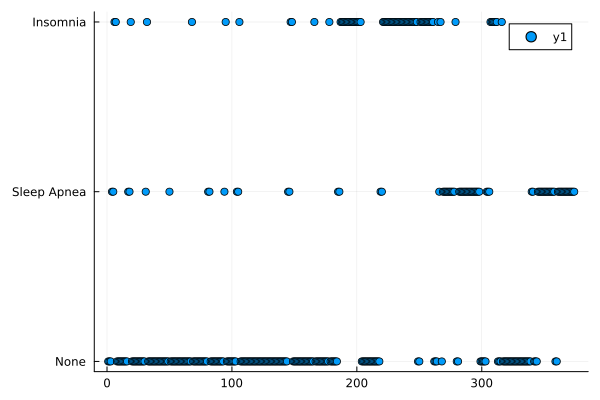

In [160]:
using Plots
scatter(df[!, "Sleep Disorder" ])

In [165]:
predictions=predict(logit,test_kopya)

112-element Vector{Union{Missing, Float64}}:
 0.0009287062935175288
 1.3481889844021276e-15
 0.9999984161957732
 0.99999762653338
 0.9397496264821389
 5.809338004018485e-7
 3.024436517350718e-17
 0.05535766258035326
 0.9397496264821389
 0.0010730019635200577
 0.05206745642492433
 8.217739792181937e-7
 0.07655071182330497
 ⋮
 0.9999983221327936
 0.9432416575771742
 0.99999762653338
 0.9999984161957732
 0.02525640318282744
 0.052270249656778484
 2.341751601823905e-17
 0.9971326103994725
 0.9689544571774493
 0.007848155362974348
 0.02829873591115907
 0.9999972573661893

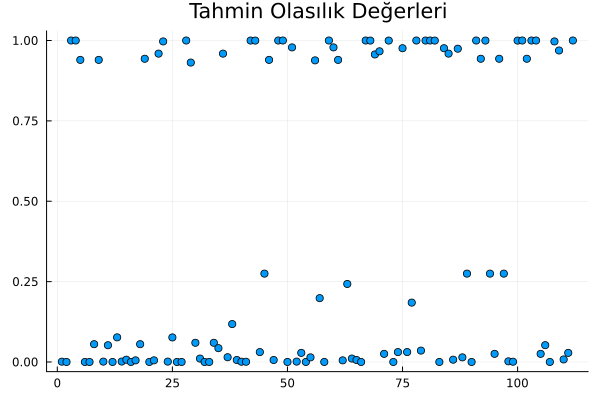

In [166]:
scatter(predictions, title="Tahmin Olasılık Değerleri",legend=false)

In [167]:
prediction_class=[if x<0.5 0 else 1 end for x in predictions]

112-element Vector{Int64}:
 0
 0
 1
 1
 1
 0
 0
 0
 1
 0
 0
 0
 0
 ⋮
 1
 1
 1
 1
 0
 0
 0
 1
 1
 0
 0
 1

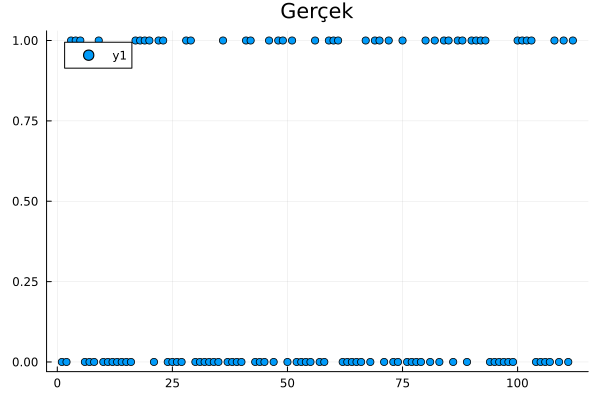

In [168]:
scatter(test_kopya[!, "Sleep Disorder"], title="Gerçek")

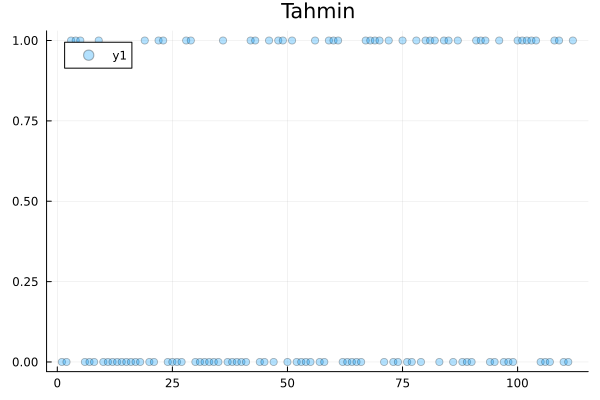

In [169]:
scatter(prediction_class, opacity=0.3, title="Tahmin")

In [171]:
prediction_df=DataFrame(y_actual=test_kopya.var"Sleep Disorder",prob_predicted=predictions,y_predicted=prediction_class)

Row,y_actual,prob_predicted,y_predicted
,Float64,Float64?,Int64
1,0.0,0.000928706,0
2,0.0,1.34819e-15,0
3,1.0,0.999998,1
4,1.0,0.999998,1
5,1.0,0.93975,1
6,0.0,5.80934e-7,0
7,0.0,3.02444e-17,0
8,0.0,0.0553577,0
9,1.0,0.93975,1


In [175]:

using MLBase

prediction_df.y_actual = Int.(prediction_df.y_actual)

confusion_matrix=MLBase.roc(prediction_df.y_actual,prediction_df.y_predicted)

ROCNums{Int64}
  p = 45
  n = 67
  tp = 38
  tn = 60
  fp = 7
  fn = 7


In [176]:
accuracy(cm)=(cm.tp+cm.tn)/(cm.tp+cm.tn+cm.fp+cm.fn)

accuracy (generic function with 1 method)

In [177]:
specificity(cm)=cm.tn/(cm.tn+cm.fp)

specificity (generic function with 1 method)

In [178]:
precision(cm)=cm.tp/(cm.tp+cm.fp)

precision (generic function with 1 method)

In [179]:
recall(cm)=cm.tp/(cm.tp+cm.fn)

recall (generic function with 1 method)

In [180]:
F1score(cm)=2*cm.tp/(2*cm.tp+cm.fp+cm.fn)

F1score (generic function with 1 method)

In [181]:
println("Accuracy: ",accuracy(confusion_matrix))
println("Specificity: ",specificity(confusion_matrix))
println("Precision: ",precision(confusion_matrix))
println("Recall: ",recall(confusion_matrix))
println("F1Score: ",F1score(confusion_matrix))

Accuracy: 0.875
Specificity: 0.8955223880597015
Precision: 0.8444444444444444
Recall: 0.8444444444444444
F1Score: 0.8444444444444444


In [189]:
##1.Doğruluk (Accuracy): %87.5
#Yorum: Modelimiz, test edilen her 100 kişiden yaklaşık 88'inin teşhisini (Hasta veya Sağlıklı olduğunu) doğru bilmiştir

##2.Özgüllük (Specificity): %89.6 
#Yorum: Modelimiz, gerçekten sağlıklı olan bireylerin %89.6'sını başarıyla ayırt etmiş ve onlara yanlışlıkla 'Hasta' dememiştir.

##3.Duyarlılık (Recall / Sensitivity): %84.4
#Yorum: "Gerçekten uyku bozukluğu olan hastaların %84.4'ünü modelimiz tespit edebilmiştir.Risk Analizi: %15.6'lık bir kesim (Gözden Kaçanlar / False Negative) mevcuttur.

##4.Kesinlik (Precision): %84.4
#Yorum: "Modelin 'Bu kişi hasta' dediği tahminlerin %84.4'ü doğrudur.

##5.F1 Skoru: %84.4 
#Yorum: "Precision ve Recall değerlerinin birebir eşit çıkması sonucunda F1 skoru da aynı değeri almıştır.Modelimiz 'Sağlıklı' sınıfı ile 'Hasta' sınıfı arasında hiçbir taraf tutmamıştır. Hem hastayı bulurken hem de sağlıklıyı ayırırken eşit performansa sahiptir.    